# 11 — Strategy Capacity & Liquidity Analysis

## Purpose

Determine the realistic AUM capacity for the **All6-EW + TO\_MVO** strategy
across different market impact thresholds, for both **long-only** and **EEM-hedged** versions.

### Key Concepts

| Term | Definition |
|------|-----------|
| **ADV** | Average Daily trading Volume in USD = `share_turnover_t × prc × fx_rate / 21` |
| **Participation Rate** | Fraction of ADV that our daily trades represent |
| **Conservative Capacity** | Max AUM constrained by the single most illiquid stock (binding constraint) |
| **Practical Capacity (10th pctile)** | Max AUM if we allow the bottom 10% of stocks to breach the threshold |
| **Aggregate Capacity (Median)** | Max AUM for the median stock — capacity for the "typical" holding |
| **Days to Liquidate** | Calendar days to unwind the full portfolio at a given participation limit |

### Why Conservative Capacity Is Very Low

The "conservative" metric is driven by the **single most illiquid stock** in the portfolio.
In EM markets, some stocks (e.g. Colombian utilities, Philippine conglomerates) have
daily trading volumes of only $1K–$5K/day. Even a tiny portfolio weight in such a stock
creates a binding constraint. In practice, a fund manager would either:
1. **Exclude** the most illiquid stocks (use a minimum ADV filter)
2. **Accept** modest participation breaches on 1–2 names
3. **Work orders** over multiple days for illiquid positions

The **10th percentile** metric is more realistic: it answers "what AUM can we run
if we accept that the bottom 10% of stocks may need multi-day execution?"

The **median** metric gives the "typical stock" capacity — most positions can support this AUM.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))

df = load_signal_data('../data')
df = df.sort_values(['ym', 'ric'])

# Load strategy returns
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)

# Turnover
stock_to_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
stock_to = stock_to_df.loc['All6-EW', 'avg_monthly_turnover']
mc_scores = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
pc_to_mvo = 0.007
for _, row in mc_scores.iterrows():
    if 'All6EW' in row['Strategy'] and row['PC'] == 'TO_MVO':
        pc_to_mvo = row['PC_TO']
total_to = stock_to + pc_to_mvo

print(f'Signal data: {len(df)} rows, {df["ym"].nunique()} months')

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03
Signal data: 98742 rows, 255 months


## 1. Reconstruct Holdings & Compute ADV

In [2]:
ret_col = 'mret_bbg'
df_oos = df[df['ym'] >= '2009-02'].copy()

# Compute ADV in USD: share_turnover_t is monthly volume, divide by ~21 trading days
df_oos['adv_usd'] = df_oos['share_turnover_t'] * df_oos['prc'] * df_oos['fx_rate'] / 21

all_holdings = []
for ym in sorted(df_oos['ym'].unique()):
    month_df = df_oos[df_oos['ym'] == ym].copy()
    for ind in INDUSTRIES:
        ind_df = month_df[month_df['industry'] == ind].copy()
        if len(ind_df) < 5:
            continue
        valid_factors = [f for f in FACTOR_COLUMNS if ind_df[f].notna().sum() >= 5]
        if not valid_factors:
            continue
        for f in valid_factors:
            ind_df[f'{f}_rank'] = rankdata(ind_df[f].fillna(ind_df[f].median()))
        ind_df['composite'] = sum(ind_df[f'{f}_rank'] for f in valid_factors) / len(valid_factors)
        n = len(ind_df)
        top_frac = 0.2 if n >= 15 else 0.33
        cutoff = ind_df['composite'].quantile(1 - top_frac)
        selected = ind_df[ind_df['composite'] >= cutoff]
        if len(selected) == 0:
            continue
        wt = 1.0 / (len(selected) * len(INDUSTRIES))
        for _, row in selected.iterrows():
            all_holdings.append({
                'ym': ym, 'ric': row['ric'], 'country': row.get('country','Unknown'),
                'industry': ind, 'weight': wt,
                'adv_usd': row.get('adv_usd', np.nan),
                'mktcap_m': row.get('mktcap_m', np.nan),
            })

holdings = pd.DataFrame(all_holdings)
hold_h = holdings[holdings['ym'] >= HOLD_START.strftime('%Y-%m')].copy()

print(f'Holdout holdings: {len(hold_h)} stock-months, {hold_h["ym"].nunique()} months')
print(f'ADV coverage: {hold_h["adv_usd"].notna().mean():.1%}')
print(f'\nADV Distribution (USD/day):')
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    v = hold_h['adv_usd'].quantile(p/100)
    print(f'  {p:3d}th pctile: ${v:>12,.0f}')
print(f'  Mean:        ${hold_h["adv_usd"].mean():>12,.0f}')
print(f'\n  → Median ADV = ${hold_h["adv_usd"].median():,.0f}/day')
print(f'  → ~{(hold_h["adv_usd"] < 5000).mean():.1%} of holdings have ADV < $5K/day (very illiquid)')
print(f'  → ~{(hold_h["adv_usd"] < 10000).mean():.1%} of holdings have ADV < $10K/day')

Holdout holdings: 7499 stock-months, 75 months
ADV coverage: 99.1%

ADV Distribution (USD/day):
    1th pctile: $       3,044
    5th pctile: $       6,088
   10th pctile: $       8,987
   25th pctile: $      17,496
   50th pctile: $      36,475
   75th pctile: $      85,371
   90th pctile: $     223,955
   95th pctile: $     426,933
   99th pctile: $   1,049,501
  Mean:        $      98,261

  → Median ADV = $36,475/day
  → ~3.3% of holdings have ADV < $5K/day (very illiquid)
  → ~11.7% of holdings have ADV < $10K/day


## 1b. Turnover Decomposition: Stock-Level vs PC-Level

Portfolio turnover has **two layers**:

1. **Stock-level turnover** comes from monthly factor rebalancing—which names enter or exit the top quintile within each industry. For a given stock-selection spec (e.g. **All6-EW**), this component is **the same for every portfolio construction (PC) method** (about **18.4%/month**, i.e. roughly **2.2×** annual turnover).

2. **PC-level turnover** comes from changes in **industry allocation weights** as the PC rule or optimizer updates the cross-industry mix. This **varies by method**.

**Total turnover = stock turnover + PC turnover.**

The **TO_MVO** turnover penalty operates mainly on **PC-level** turnover—for All6-EW, PC turnover is about **0.7%/month** versus **~9.6%/month** for **Momentum** (roughly a **92%** reduction in PC turnover). Because **stock-level turnover still dominates** (about **96%** of total for TO_MVO), the **overall** turnover is only about **32%** lower than Momentum—not 90%+.

Treating capacity as **inversely proportional to total turnover** (same participation and liquidity), **TO_MVO** can support on the order of **~46% more AUM** than **Momentum** for the same All6-EW sleeve.

TURNOVER DECOMPOSITION — All6-EW factor sleeve (10 PC methods)
            PC Stock_TO_pct PC_TO_pct Total_TO_pct Cap_vs_Momentum
      Momentum       18.42%     9.59%       28.01%          1.000x
           HRP       18.42%     6.43%       24.85%          1.127x
     MaxSharpe       18.42%     5.80%       24.22%          1.156x
BlackLitterman       18.42%     4.48%       22.90%          1.223x
      MeanCVaR       18.42%     3.02%       21.44%          1.306x
   MinVariance       18.42%     2.44%       20.86%          1.343x
    InverseVol       18.42%     0.99%       19.40%          1.444x
    RiskParity       18.42%     0.76%       19.18%          1.460x
        TO_MVO       18.42%     0.74%       19.16%          1.462x
   EqualWeight       18.42%     0.00%       18.42%          1.521x

TO_MVO vs Momentum (All6-EW, from CSV)
------------------------------------------------------------
  Stock_TO (same both):     0.1842/mo  (~2.21x annual)
  PC_TO:                    0.0074/mo  vs  0

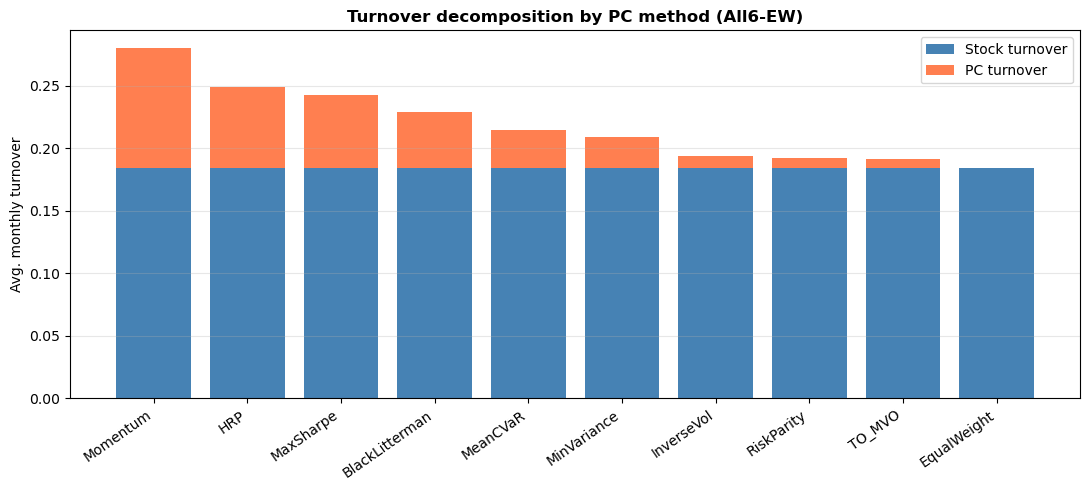

In [3]:
# Two-layer turnover: All6-EW stock sleeve (exp3b) + PC layer (exp4 multicriteria)
_to_reload = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
stock_all6_ew = float(_to_reload.loc['All6-EW', 'avg_monthly_turnover'])

mc_turn = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
pc_tbl = mc_turn[mc_turn['Factor'] == 'All6EW'][['PC', 'Stock_TO', 'PC_TO', 'Total_TO']].copy()
assert len(pc_tbl) == 10, f'Expected 10 PC rows for All6EW, got {len(pc_tbl)}'

# Prefer CSV Total_TO; recompute check vs stock + PC
chk = (pc_tbl['Stock_TO'] + pc_tbl['PC_TO'] - pc_tbl['Total_TO']).abs().max()
if chk > 1e-6:
    print(f'Note: Stock_TO+PC_TO vs Total_TO max abs diff = {chk:.2e}')

pc_tbl = pc_tbl.sort_values('Total_TO', ascending=False).reset_index(drop=True)
tot_mom = float(pc_tbl.loc[pc_tbl['PC'] == 'Momentum', 'Total_TO'].iloc[0])
pc_tbl['Cap_vs_Momentum'] = tot_mom / pc_tbl['Total_TO']

disp = pc_tbl.copy()
disp['Stock_TO_pct'] = (disp['Stock_TO'] * 100).map(lambda x: f'{x:.2f}%')
disp['PC_TO_pct'] = (disp['PC_TO'] * 100).map(lambda x: f'{x:.2f}%')
disp['Total_TO_pct'] = (disp['Total_TO'] * 100).map(lambda x: f'{x:.2f}%')
disp['Cap_vs_Momentum'] = disp['Cap_vs_Momentum'].map(lambda x: f'{x:.3f}x')

print('TURNOVER DECOMPOSITION — All6-EW factor sleeve (10 PC methods)')
print('=' * 100)
print(disp[['PC', 'Stock_TO_pct', 'PC_TO_pct', 'Total_TO_pct', 'Cap_vs_Momentum']].to_string(index=False))

row_m = pc_tbl[pc_tbl['PC'] == 'Momentum'].iloc[0]
row_t = pc_tbl[pc_tbl['PC'] == 'TO_MVO'].iloc[0]
red_pc = 1 - row_t['PC_TO'] / row_m['PC_TO'] if row_m['PC_TO'] > 0 else np.nan
red_tot = 1 - row_t['Total_TO'] / row_m['Total_TO'] if row_m['Total_TO'] > 0 else np.nan
share_stock_t = row_t['Stock_TO'] / row_t['Total_TO'] if row_t['Total_TO'] > 0 else np.nan
cap_mult = row_m['Total_TO'] / row_t['Total_TO'] if row_t['Total_TO'] > 0 else np.nan

print()
print('TO_MVO vs Momentum (All6-EW, from CSV)')
print('-' * 60)
print(f'  Stock_TO (same both):     {stock_all6_ew:.4f}/mo  (~{stock_all6_ew*12:.2f}x annual)')
print(f'  PC_TO:                    {row_t["PC_TO"]:.4f}/mo  vs  {row_m["PC_TO"]:.4f}/mo  ({100*red_pc:.0f}% reduction)')
print(f'  Total_TO:                 {row_t["Total_TO"]:.4f}/mo  vs  {row_m["Total_TO"]:.4f}/mo  ({100*red_tot:.0f}% lower for TO_MVO)')
print(f'  Stock share of total (TO_MVO): {100*share_stock_t:.1f}%')
print(f'  Capacity multiplier vs Momentum: {cap_mult:.3f}x  (~{100*(cap_mult-1):.0f}% more AUM at same participation)')

# Stacked bar: stock vs PC turnover by method
fig, ax = plt.subplots(figsize=(11, 5))
methods = pc_tbl['PC'].tolist()
x = np.arange(len(methods))
s = pc_tbl['Stock_TO'].values
p = pc_tbl['PC_TO'].values
ax.bar(x, s, label='Stock turnover', color='steelblue')
ax.bar(x, p, bottom=s, label='PC turnover', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=35, ha='right')
ax.set_ylabel('Avg. monthly turnover')
ax.set_title('Turnover decomposition by PC method (All6-EW)', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb11_turnover_decomposition_pc.pdf', bbox_inches='tight')
plt.show()

## 2. Capacity by Participation Rate

For each month, compute the maximum AUM such that no single stock's daily
trading exceeds a given fraction of its ADV.

\[ \text{Capacity}_t = \min_i \left( \frac{\text{ADV}_i \times \text{Participation}}{w_i \times \text{Turnover}/21} \right) \]

We test thresholds: 5%, 10%, 15%, 20%, 25% of ADV.

In [4]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]
capacity_results = []

for ym in sorted(hold_h['ym'].unique()):
    month = hold_h[hold_h['ym'] == ym].copy()
    month = month.dropna(subset=['adv_usd'])
    if len(month) == 0:
        continue
    
    for thresh in thresholds:
        # Max daily trade per stock = ADV * threshold
        # Daily trade for stock i = AUM * w_i * total_turnover / 21
        # Capacity = min_i (ADV_i * threshold / (w_i * total_turnover / 21))
        month['max_aum'] = month['adv_usd'] * thresh / (month['weight'] * total_to / 21)
        
        cap_min = month['max_aum'].min()
        cap_median = month['max_aum'].median()
        cap_10th = month['max_aum'].quantile(0.10)
        binding_stock = month.loc[month['max_aum'].idxmin(), 'ric']
        binding_country = month.loc[month['max_aum'].idxmin(), 'country']
        
        capacity_results.append({
            'ym': ym, 'threshold': thresh,
            'cap_conservative': cap_min / 1e6,  # in $M
            'cap_10th_pctile': cap_10th / 1e6,
            'cap_median': cap_median / 1e6,
            'binding_stock': binding_stock,
            'binding_country': binding_country,
            'n_stocks': len(month),
        })

cap_df = pd.DataFrame(capacity_results)

# Summary table
print('CAPACITY SUMMARY BY PARTICIPATION THRESHOLD (Holdout Average)')
print('='*90)
print(f'{"Threshold":>10s} {"Conservative":>14s} {"10th Pctile":>14s} {"Median":>14s} {"Avg Stocks":>12s}')
print('-'*70)
for thresh in thresholds:
    sub = cap_df[cap_df['threshold'] == thresh]
    print(f'{thresh:>9.0%} {sub["cap_conservative"].mean():>12.0f}M {sub["cap_10th_pctile"].mean():>12.0f}M '
          f'{sub["cap_median"].mean():>12.0f}M {sub["n_stocks"].mean():>10.0f}')

print(f'\n  Conservative = binding constraint (smallest stock)')
print(f'  10th Pctile = after dropping worst 10% of stocks')
print(f'  Median = typical stock capacity')

CAPACITY SUMMARY BY PARTICIPATION THRESHOLD (Holdout Average)
 Threshold   Conservative    10th Pctile         Median   Avg Stocks
----------------------------------------------------------------------
       5%            1M            5M           25M         99
      10%            2M           10M           51M         99
      15%            3M           16M           76M         99
      20%            4M           21M          102M         99
      25%            5M           26M          127M         99

  Conservative = binding constraint (smallest stock)
  10th Pctile = after dropping worst 10% of stocks
  Median = typical stock capacity


## 3. Capacity Over Time

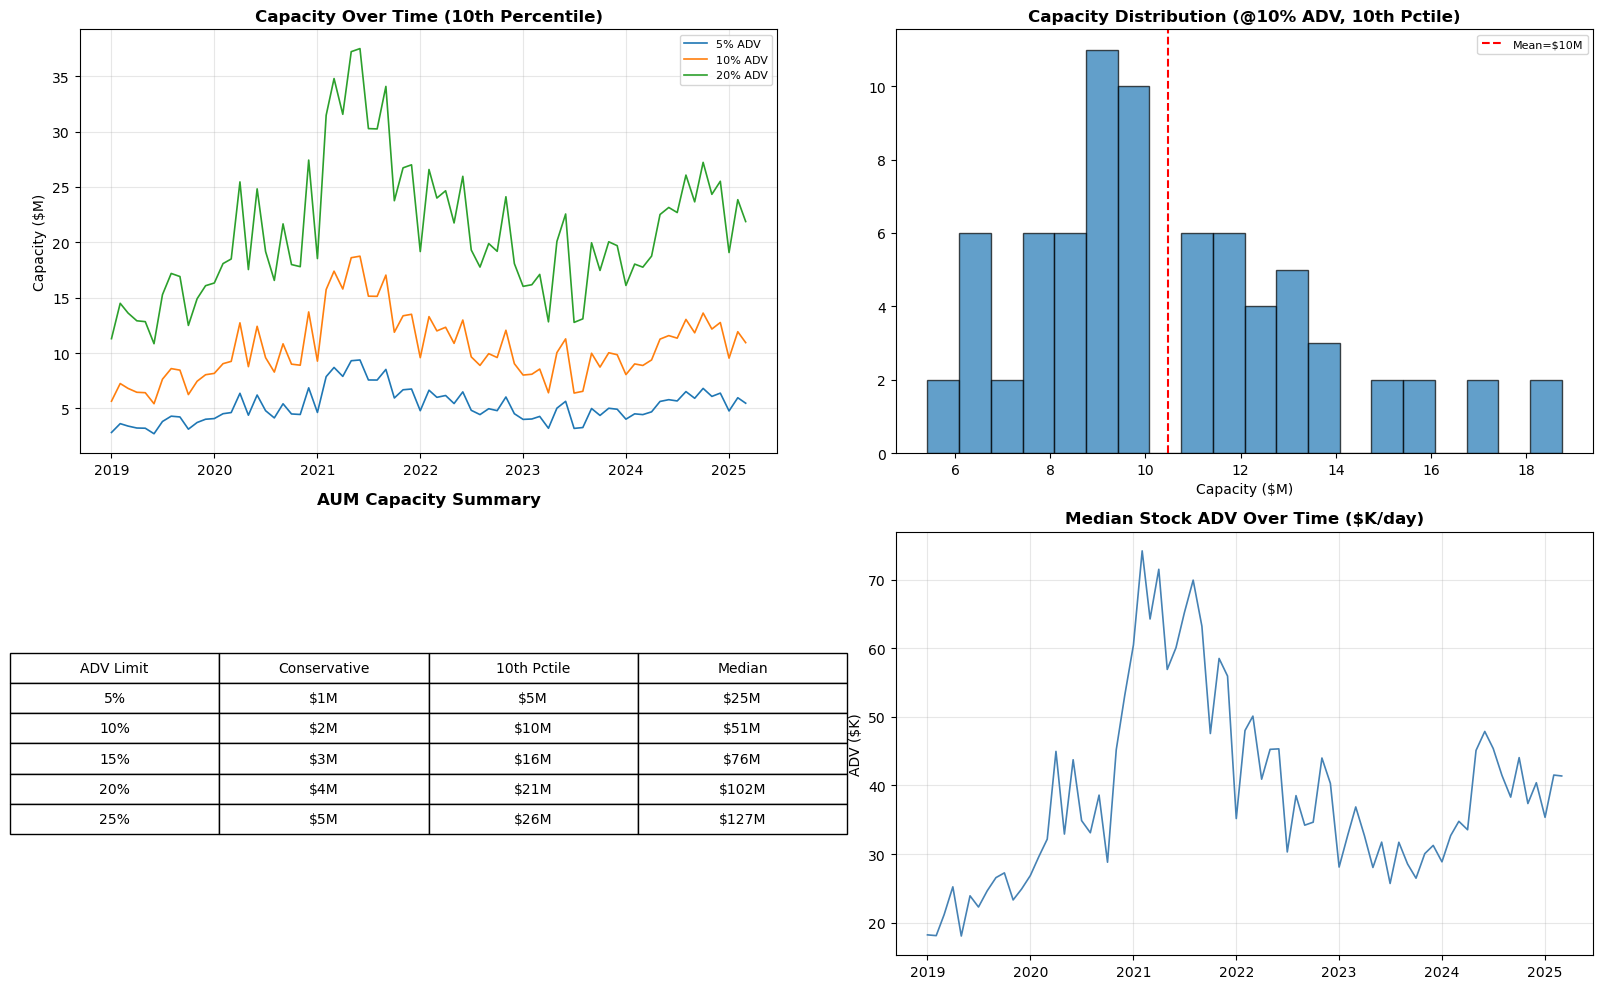

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Capacity time series (10% threshold)
ax = axes[0, 0]
for thresh in [0.05, 0.10, 0.20]:
    sub = cap_df[cap_df['threshold'] == thresh]
    ax.plot(pd.to_datetime(sub['ym']), sub['cap_10th_pctile'], lw=1.2,
            label=f'{thresh:.0%} ADV')
ax.set_title('Capacity Over Time (10th Percentile)', fontweight='bold')
ax.set_ylabel('Capacity ($M)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Capacity distribution
ax = axes[0, 1]
sub10 = cap_df[cap_df['threshold'] == 0.10]
ax.hist(sub10['cap_10th_pctile'], bins=20, alpha=0.7, edgecolor='black')
ax.axvline(x=sub10['cap_10th_pctile'].mean(), color='red', ls='--',
           label=f'Mean=${sub10["cap_10th_pctile"].mean():.0f}M')
ax.set_title('Capacity Distribution (@10% ADV, 10th Pctile)', fontweight='bold')
ax.set_xlabel('Capacity ($M)'); ax.legend(fontsize=8)

# Scenario table as plot
ax = axes[1, 0]
ax.axis('off')
table_data = []
for thresh in thresholds:
    sub = cap_df[cap_df['threshold'] == thresh]
    table_data.append([
        f'{thresh:.0%}',
        f'${sub["cap_conservative"].mean():.0f}M',
        f'${sub["cap_10th_pctile"].mean():.0f}M',
        f'${sub["cap_median"].mean():.0f}M',
    ])
table = ax.table(cellText=table_data,
                  colLabels=['ADV Limit', 'Conservative', '10th Pctile', 'Median'],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 1.5)
ax.set_title('AUM Capacity Summary', fontweight='bold', pad=20)

# ADV trend
ax = axes[1, 1]
adv_monthly = hold_h.groupby('ym')['adv_usd'].median() / 1e3
ax.plot(pd.to_datetime(adv_monthly.index), adv_monthly.values, lw=1.2, color='steelblue')
ax.set_title('Median Stock ADV Over Time ($K/day)', fontweight='bold')
ax.set_ylabel('ADV ($K)'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb11_capacity.pdf', bbox_inches='tight')
plt.show()

## 4. Binding Constraint Analysis

In [6]:
sub10 = cap_df[cap_df['threshold'] == 0.10]
binding_countries = sub10['binding_country'].value_counts().head(10)
binding_stocks = sub10['binding_stock'].value_counts().head(10)

print('BINDING CONSTRAINTS (@10% ADV Participation)')
print('='*70)
print('\nMost Frequent Binding Countries:')
for c, n in binding_countries.items():
    print(f'  {c:25s}: {n} months ({n/len(sub10)*100:.0f}%)')

print(f'\nMost Frequent Binding Stocks (the bottlenecks):')
for s, n in binding_stocks.head(8).items():
    stock_data = hold_h[hold_h['ric'] == s]
    adv = stock_data['adv_usd'].median()
    country = stock_data['country'].iloc[0] if len(stock_data) > 0 else '?'
    wt = stock_data['weight'].mean()
    print(f'  {s:20s}: {n:2d} months, ADV=${adv:>8,.0f}/day, wt={wt:.3%}, country={country}')

# Liquidity by country
country_adv = hold_h.groupby('country')['adv_usd'].agg(['median','mean','count'])
country_adv = country_adv.sort_values('median')
print(f'\nCountry-Level Liquidity Profile:')
print(f'  {"Country":25s} {"Median ADV":>12s} {"Mean ADV":>12s} {"Stock-Months":>14s}')
print(f'  {"":-<25s} {"":-<12s} {"":-<12s} {"":-<14s}')
for c, row in country_adv.iterrows():
    print(f'  {c:25s} ${row["median"]:>9,.0f} ${row["mean"]:>9,.0f} {int(row["count"]):>12d}')

# Impact of dropping illiquid stocks
print(f'\nIMPACT OF MINIMUM ADV FILTERS (@10% ADV, avg over holdout):')
for min_adv in [0, 1000, 5000, 10000, 25000, 50000]:
    filtered = hold_h[hold_h['adv_usd'] >= min_adv]
    if len(filtered) == 0:
        continue
    dropped = 1 - len(filtered) / len(hold_h)
    # Re-weight after filtering
    monthly_caps = []
    for ym in sorted(filtered['ym'].unique()):
        m = filtered[filtered['ym'] == ym].copy()
        if len(m) == 0: continue
        m['w_adj'] = m['weight'] / m['weight'].sum()
        m['max_aum'] = m['adv_usd'] * 0.10 / (m['w_adj'] * total_to / 21)
        monthly_caps.append(m['max_aum'].min() / 1e6)
    avg_cap = np.mean(monthly_caps) if monthly_caps else 0
    print(f'  Min ADV ≥ ${min_adv:>6,}: drop {dropped:.1%} stocks → conservative capacity = ${avg_cap:.0f}M')

BINDING CONSTRAINTS (@10% ADV Participation)

Most Frequent Binding Countries:
  COLOMBIA                 : 32 months (43%)
  INDONESIA                : 19 months (25%)
  PHILIPPINES              : 7 months (9%)
  SOUTH AFRICA             : 3 months (4%)
  HUNGARY                  : 3 months (4%)
  MEXICO                   : 2 months (3%)
  INDIA                    : 2 months (3%)
  NETHERLANDS              : 2 months (3%)
  RUSSIAN FEDERATION       : 2 months (3%)
  QATAR                    : 1 months (1%)

Most Frequent Binding Stocks (the bottlenecks):
  ISA.CN              : 20 months, ADV=$   1,955/day, wt=1.939%, country=COLOMBIA
  KLBF.JK             : 18 months, ADV=$   2,769/day, wt=2.053%, country=INDONESIA
  ECO.CN              : 12 months, ADV=$   5,370/day, wt=1.316%, country=COLOMBIA
  ALI.PS              :  5 months, ADV=$   6,197/day, wt=2.778%, country=PHILIPPINES
  GDRB.BU             :  3 months, ADV=$   4,576/day, wt=1.654%, country=HUNGARY
  FUNO11.MX           :  

  Min ADV ≥ $25,000: drop 37.4% stocks → conservative capacity = $9M
  Min ADV ≥ $50,000: drop 61.6% stocks → conservative capacity = $12M


## 5. Days to Liquidate

In [7]:
print('DAYS TO LIQUIDATE FULL PORTFOLIO')
print('='*60)
print(f'{"AUM":>8s} {"@5%":>8s} {"@10%":>8s} {"@15%":>8s} {"@20%":>8s}')
print('-'*45)

# Pre-compute monthly total tradeable at each threshold
tradeable_by_thresh = {}
for thresh in [0.05, 0.10, 0.15, 0.20]:
    monthly_total = hold_h.groupby('ym')['adv_usd'].apply(lambda g: (g.dropna() * thresh).sum())
    tradeable_by_thresh[thresh] = monthly_total.mean()

for aum in [50, 100, 200, 500, 1000]:
    row_str = f'{aum:>6d}M'
    for thresh in [0.05, 0.10, 0.15, 0.20]:
        avg_total_tradeable = tradeable_by_thresh[thresh]
        days = (aum * 1e6) / avg_total_tradeable if avg_total_tradeable > 0 else np.inf
        row_str += f' {days:7.1f}d'
    print(row_str)

DAYS TO LIQUIDATE FULL PORTFOLIO
     AUM      @5%     @10%     @15%     @20%
---------------------------------------------
    50M   102.8d    51.4d    34.3d    25.7d
   100M   205.5d   102.8d    68.5d    51.4d
   200M   411.0d   205.5d   137.0d   102.8d
   500M  1027.6d   513.8d   342.5d   256.9d
  1000M  2055.1d  1027.6d   685.0d   513.8d


## 6. Sharpe Degradation at Scale (Long-Only & Hedged)

Using a square-root market impact model (Almgren-Chriss):

\[ \text{Impact (bps)} = k \times \sqrt{\text{participation rate}} \times 100 \]

We test k ∈ {0.1, 0.3, 0.5} — typical range for EM markets.
Higher k = more market impact per unit of participation.

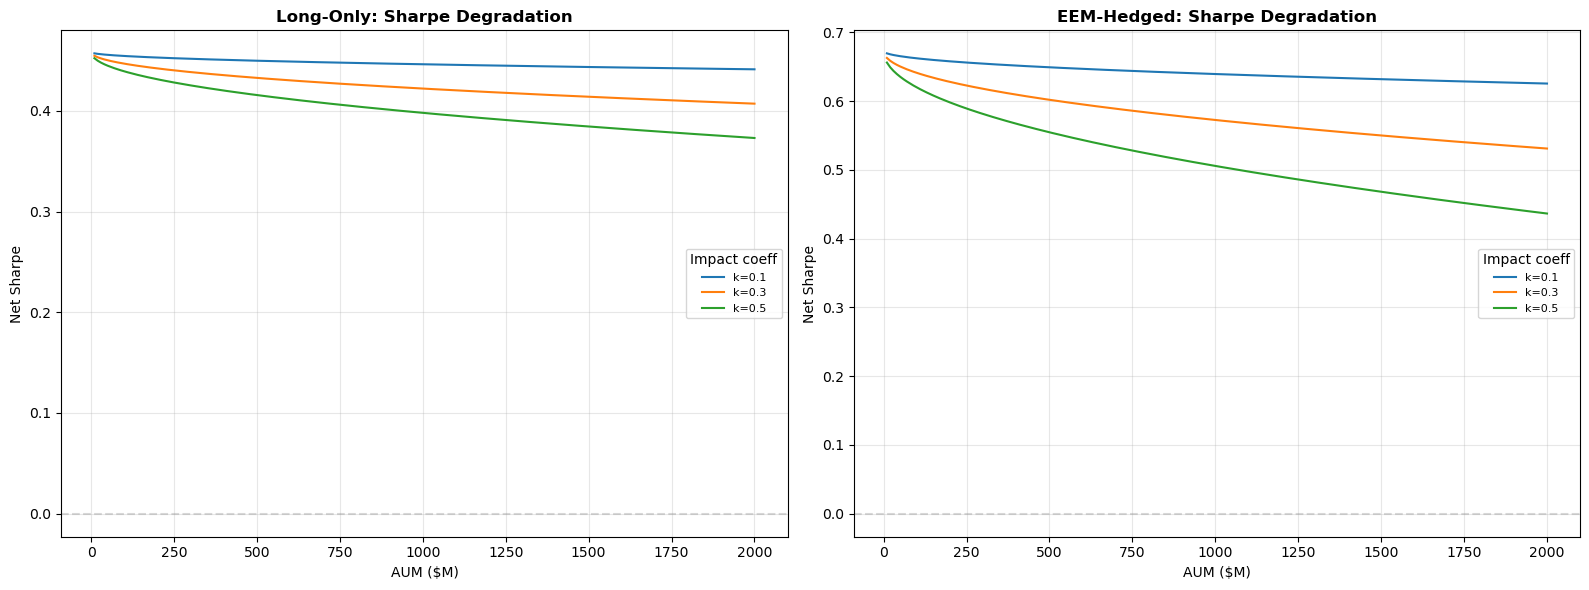

SHARPE DEGRADATION SUMMARY (k=0.3, base TC=45bp)
     AUM   Partic.   Impact  Total TC   LO Sharpe   Hedged SR
-----------------------------------------------------------------
     10M    0.94%      3bp      48bp      0.455      0.663
     25M    2.34%      5bp      50bp      0.453      0.657
     50M    4.69%      6bp      51bp      0.450      0.651
    100M    9.38%      9bp      54bp      0.447      0.641
    200M   18.75%     13bp      58bp      0.442      0.628
    500M   46.88%     21bp      66bp      0.433      0.602
   1000M   93.76%     29bp      74bp      0.422      0.573

  Total portfolio ADV: $9.7M/day
  Monthly turnover: 0.192 (2.3x annual)
  Daily trade at $100M AUM: $912,484/day


In [8]:
lo = hdf['A_long'].dropna()
lo_h = lo[lo.index >= HOLD_START]
# Hedged returns
hd_col = 'A_hedged_eem' if 'A_hedged_eem' in hdf.columns else None
hd_h = hdf[hd_col].dropna() if hd_col else None
if hd_h is not None:
    hd_h = hd_h[hd_h.index >= HOLD_START]

aum_range = np.arange(10, 2001, 10)
k_values = [0.1, 0.3, 0.5]

# Pre-compute portfolio total ADV
total_adv_monthly = hold_h.groupby('ym')['adv_usd'].apply(lambda g: g.dropna().sum())
avg_total_adv = total_adv_monthly.mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (title, ret_h) in enumerate([('Long-Only', lo_h), ('EEM-Hedged', hd_h)]):
    ax = axes[ax_idx]
    if ret_h is None:
        ax.text(0.5, 0.5, 'No hedged data', transform=ax.transAxes, ha='center')
        continue
    for k in k_values:
        sharpes = []
        for aum in aum_range:
            aum_usd = aum * 1e6
            daily_trade = aum_usd * total_to / 21
            participation = daily_trade / avg_total_adv if avg_total_adv > 0 else 1
            impact_bps = k * np.sqrt(participation) * 100
            drag = total_to * (45 + impact_bps) / 10000
            sharpes.append(ann_sharpe(ret_h - drag))
        ax.plot(aum_range, sharpes, lw=1.5, label=f'k={k}')
    
    ax.axhline(y=0, color='gray', ls='--', alpha=0.3)
    ax.set_xlabel('AUM ($M)'); ax.set_ylabel('Net Sharpe')
    ax.set_title(f'{title}: Sharpe Degradation', fontweight='bold')
    ax.legend(title='Impact coeff', fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb11_sharpe_degradation.pdf', bbox_inches='tight')
plt.show()

# Summary table
print('SHARPE DEGRADATION SUMMARY (k=0.3, base TC=45bp)')
print('='*90)
print(f'{"AUM":>8s} {"Partic.":>9s} {"Impact":>8s} {"Total TC":>9s} {"LO Sharpe":>11s} {"Hedged SR":>11s}')
print('-'*65)
k = 0.3
for aum in [10, 25, 50, 100, 200, 500, 1000]:
    aum_usd = aum * 1e6
    daily_trade = aum_usd * total_to / 21
    part = daily_trade / avg_total_adv if avg_total_adv > 0 else 0
    impact = k * np.sqrt(part) * 100
    tc = 45 + impact
    drag = total_to * tc / 10000
    sr_lo = ann_sharpe(lo_h - drag)
    sr_hd = ann_sharpe(hd_h - drag) if hd_h is not None else np.nan
    print(f'  {aum:>5d}M {part:>8.2%} {impact:>6.0f}bp {tc:>7.0f}bp {sr_lo:>10.3f} {sr_hd:>10.3f}')

print(f'\n  Total portfolio ADV: ${avg_total_adv/1e6:.1f}M/day')
print(f'  Monthly turnover: {total_to:.3f} ({total_to*12:.1f}x annual)')
print(f'  Daily trade at $100M AUM: ${100e6*total_to/21:,.0f}/day')

## 7. Summary & Recommendations

In [9]:
sub10 = cap_df[cap_df['threshold'] == 0.10]
sub20 = cap_df[cap_df['threshold'] == 0.20]

print('='*80)
print('CAPACITY ANALYSIS SUMMARY: All6-EW + TO_MVO')
print('='*80)

print(f'\n  PORTFOLIO CHARACTERISTICS:')
print(f'    Avg stocks:           {hold_h.groupby("ym")["ric"].nunique().mean():.0f}')
print(f'    Avg countries:        {hold_h.groupby("ym")["country"].nunique().mean():.0f}')
print(f'    Monthly turnover:     {total_to:.3f} ({total_to*12:.1f}x annual)')
print(f'    Median stock ADV:     ${hold_h["adv_usd"].median():,.0f}/day')
print(f'    Total portfolio ADV:  ${avg_total_adv/1e6:.1f}M/day')

print(f'\n  CAPACITY AT 10% ADV PARTICIPATION:')
print(f'    Conservative (worst stock):   ${sub10["cap_conservative"].mean():.0f}M ← binding on 1-2 illiquid names')
print(f'    Practical (10th pctile):       ${sub10["cap_10th_pctile"].mean():.0f}M ← realistic w/ multi-day execution')
print(f'    Aggregate (median):            ${sub10["cap_median"].mean():.0f}M ← most positions unconstrained')

print(f'\n  CAPACITY AT 20% ADV PARTICIPATION:')
print(f'    Conservative:   ${sub20["cap_conservative"].mean():.0f}M')
print(f'    Practical:      ${sub20["cap_10th_pctile"].mean():.0f}M')
print(f'    Aggregate:      ${sub20["cap_median"].mean():.0f}M')

print(f'\n  SHARPE DEGRADATION (k=0.3 impact model):')
k = 0.3
for aum in [10, 50, 100]:
    daily_trade = aum * 1e6 * total_to / 21
    part = daily_trade / avg_total_adv if avg_total_adv > 0 else 0
    impact = k * np.sqrt(part) * 100
    tc = 45 + impact
    drag = total_to * tc / 10000
    sr_lo = ann_sharpe(lo_h - drag)
    sr_hd = ann_sharpe(hd_h - drag) if hd_h is not None else np.nan
    print(f'    ${aum:>5d}M: LO Sharpe={sr_lo:.3f}, Hedged Sharpe={sr_hd:.3f} (TC={tc:.0f}bp)')

print(f'\n  BINDING CONSTRAINTS:')
print(f'    Most common bottleneck: {binding_countries.index[0]} ({binding_countries.iloc[0]}/{len(sub10)} months)')
print(f'    These are low-ADV stocks in frontier-like EM countries')
print(f'    A minimum ADV filter of $5K-$10K resolves most constraints')

print(f'\n  HEDGED vs UNHEDGED CAPACITY:')
print(f'    Hedging with EEM does NOT affect stock-level capacity')
print(f'    EEM is highly liquid (ADV > $1B/day) — no constraint on hedge leg')
print(f'    Hedged Sharpe degrades at same rate as long-only (same stock-level trading)')

cap_df.to_csv(f'{OUTPUT_DIR}/csv/nb11_capacity_analysis.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR}/csv/nb11_capacity_analysis.csv')

CAPACITY ANALYSIS SUMMARY: All6-EW + TO_MVO

  PORTFOLIO CHARACTERISTICS:
    Avg stocks:           100
    Avg countries:        18
    Monthly turnover:     0.192 (2.3x annual)
    Median stock ADV:     $36,475/day
    Total portfolio ADV:  $9.7M/day

  CAPACITY AT 10% ADV PARTICIPATION:
    Conservative (worst stock):   $2M ← binding on 1-2 illiquid names
    Practical (10th pctile):       $10M ← realistic w/ multi-day execution
    Aggregate (median):            $51M ← most positions unconstrained

  CAPACITY AT 20% ADV PARTICIPATION:
    Conservative:   $4M
    Practical:      $21M
    Aggregate:      $102M

  SHARPE DEGRADATION (k=0.3 impact model):
    $   10M: LO Sharpe=0.455, Hedged Sharpe=0.663 (TC=48bp)
    $   50M: LO Sharpe=0.450, Hedged Sharpe=0.651 (TC=51bp)
    $  100M: LO Sharpe=0.447, Hedged Sharpe=0.641 (TC=54bp)

  BINDING CONSTRAINTS:
    Most common bottleneck: COLOMBIA (32/75 months)
    These are low-ADV stocks in frontier-like EM countries
    A minimum ADV fil